# Getting Started with OpenCV and Computer Vision

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [2]:
# img = cv2.imread("./Images/fruit.png")

# cv2.imshow("Fruit Image", img)

# cv2.waitKey(0)          # hold window open until key press
# cv2.destroyAllWindows() # clean up

#### *`Work with Numpy Matplotlib and OpenCV all together`*

- *`Stage 1 — Create Images from Scratch with NumPy:`* Before loading any real image, let's build images manually so you see exactly what's happening.

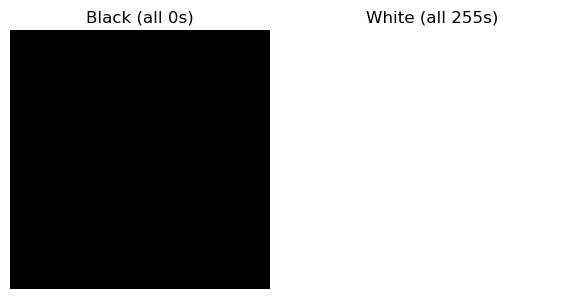

In [3]:
black = np.zeros((200, 200), dtype=np.uint8)
white = np.ones((200, 200), dtype=np.uint8) * 255

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

# vmin=0: Maps the value 0 to absolute black
# vmax=255: Maps the value 255 to absolute white
# This ensures 0 actually looks black even if there are no other values in the array
axes[0].imshow(black, cmap="gray", vmin=0, vmax=255) 
axes[0].set_title("Black (all 0s)")
axes[0].axis("off")

# We keep the same vmin/vmax here so the "white" array is compared 
# against the same 0-255 scale as the "black" array
axes[1].imshow(white, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("White (all 255s)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


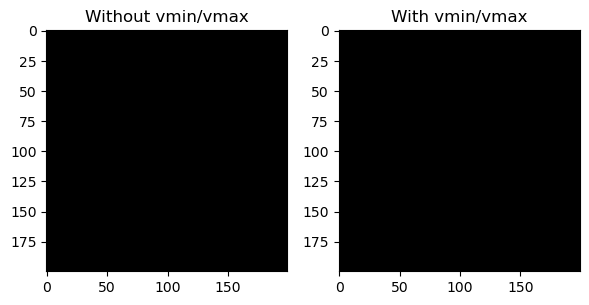

In [4]:
# What happens WITHOUT vmin/vmax on a black image?
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(black, cmap='gray')              # no vmin/vmax
axes[0].set_title("Without vmin/vmax")

axes[1].imshow(black, cmap='gray', vmin=0, vmax=255)  # with vmin/vmax
axes[1].set_title("With vmin/vmax")

plt.tight_layout()
plt.show()

# You'll see: left looks weird, right looks correct black

Shape: (200, 400)
Dtype: uint8
Min: 0 Max: 255


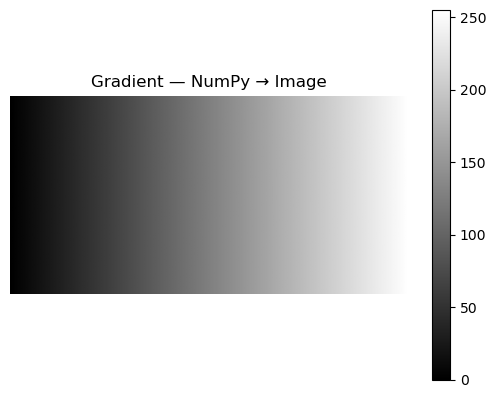

In [ ]:
# np.linspace gives evenly spaced values → perfect for a gradient
row = np.linspace(0, 255, 400, dtype=np.uint8)  # 1D: it means start from 0, stop at 255 and 400 values(columns)

# Stack same row 200 times to make a 2D image
gradient = np.tile(row, (200, 1))  # shape → (200, 400)
# The Breakdown

#     row: This is a single 1D line of 400 pixels that fades from black (0) to white (255). Think of it as a thin strip of paper.
#     (200, 1): This tells NumPy how to repeat that strip:
#         200: Repeat the row 200 times vertically (adding rows).
#         1: Repeat the row 1 time horizontally (keeping the width the same).

print("Shape:", gradient.shape)    # (200, 400)
print("Dtype:", gradient.dtype)    # uint8
print("Min:", gradient.min(), "Max:", gradient.max())

plt.imshow(gradient, cmap='gray', vmin=0, vmax=255)
plt.title("Gradient — NumPy → Image")
plt.axis('off')
plt.colorbar()   # shows intensity scale
plt.show()

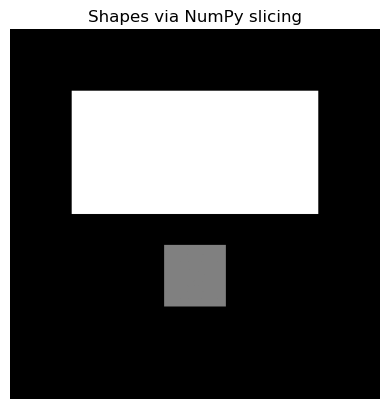

In [6]:
# Start with black canvas
canvas = np.zeros((300, 300), dtype=np.uint8)

# Draw a white rectangle using array slicing
# canvas[y1:y2, x1:x2] = value  ← remember: rows first (y), cols second (x)
canvas[50:150, 50:250] = 255      # white rectangle
canvas[175:225, 125:175] = 128    # gray square

plt.imshow(canvas, cmap='gray', vmin=0, vmax=255)
plt.title("Shapes via NumPy slicing")
plt.axis('off')
plt.show()

Shape: (200, 300, 3)
Dtype: uint8


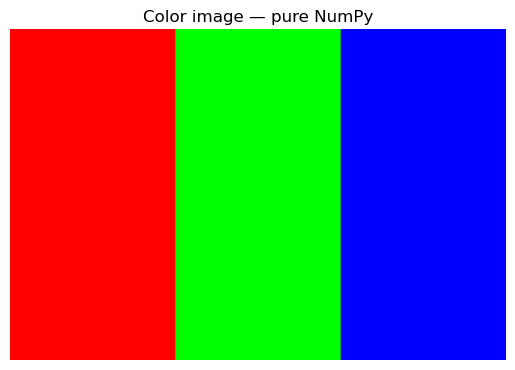

In [7]:
# 3D array → shape (H, W, 3)
# Last dimension = [R, G, B] for matplotlib
color_img = np.zeros((200, 300, 3), dtype=np.uint8)

print("Shape:", color_img.shape)   # (200, 300, 3)
print("Dtype:", color_img.dtype)   # uint8

# Paint regions with color using slicing
color_img[0:200,   0:100]  = [255, 0,   0]   # Red region
color_img[0:200, 100:200]  = [0,   255, 0]   # Green region
color_img[0:200, 200:300]  = [0,   0, 255]   # Blue region

plt.imshow(color_img)   # no cmap needed for color!
plt.title("Color image — pure NumPy")
plt.axis('off')
plt.show()

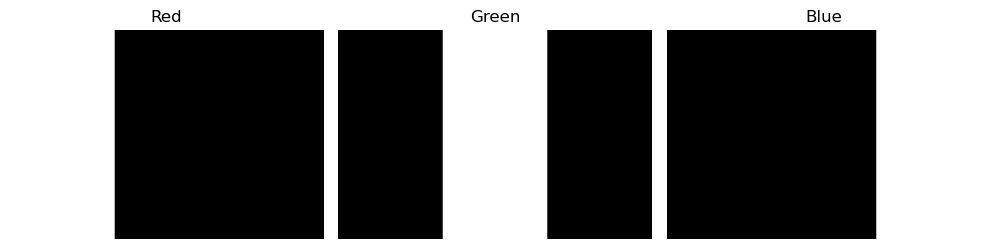

In [8]:
# Split into 3 separate 2D arrays
r_channel = color_img[:, :, 0]   # shape (200, 300)
g_channel = color_img[:, :, 1]
b_channel = color_img[:, :, 2]

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, ch, title in zip(axes,
                          [r_channel, g_channel, b_channel],
                          ["Red", "Green", "Blue"]):
    ax.imshow(ch, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

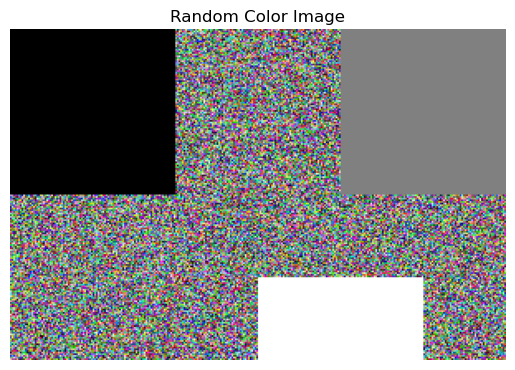

In [25]:
# random values between 0-255, shape (200, 300, 3) → color image
random_img = np.random.randint(0, 255, (200, 300, 3))
random_img[0:100, 0:100] = 0
random_img[150:200, 150:250] = 255
random_img[0:100, -100:] = 128
plt.imshow(random_img)
plt.title("Random Color Image")
plt.axis('off')
plt.show()


<class 'numpy.ndarray'>
(3264, 4928, 3)
uint8


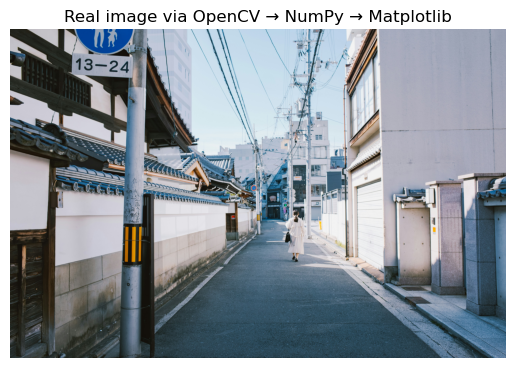

Patch shape: (10, 10, 3)
Patch values:
 [[[35 36 30]
  [38 39 33]
  [37 38 32]
  [35 36 30]
  [33 34 28]
  [34 35 29]
  [33 34 26]
  [34 35 27]
  [34 35 27]
  [33 34 26]]

 [[32 33 27]
  [32 33 27]
  [32 33 27]
  [32 33 27]
  [34 35 29]
  [37 38 32]
  [34 35 27]
  [35 36 28]
  [36 37 29]
  [33 34 26]]

 [[30 31 25]
  [30 31 25]
  [30 31 25]
  [31 32 26]
  [33 34 28]
  [35 36 30]
  [32 33 25]
  [34 35 27]
  [35 36 28]
  [35 36 28]]

 [[34 35 29]
  [35 36 30]
  [36 37 31]
  [34 35 29]
  [33 34 28]
  [33 34 28]
  [30 31 23]
  [32 33 25]
  [35 36 28]
  [37 38 30]]

 [[30 31 23]
  [31 32 24]
  [37 38 30]
  [34 35 27]
  [30 31 23]
  [36 37 29]
  [29 30 22]
  [34 35 27]
  [33 34 26]
  [33 34 26]]

 [[31 32 24]
  [33 34 26]
  [35 36 28]
  [33 34 26]
  [32 33 25]
  [36 37 29]
  [29 30 22]
  [35 36 28]
  [35 36 28]
  [35 36 28]]

 [[36 37 29]
  [36 37 29]
  [33 34 26]
  [32 33 25]
  [34 35 27]
  [33 34 26]
  [30 31 23]
  [37 38 30]
  [38 39 31]
  [36 37 29]]

 [[34 35 27]
  [36 37 29]
  [31 32 2

In [9]:
# Step 1: OpenCV loads image → immediately becomes a NumPy array
img_bgr = cv2.imread("./Images/japan_street.jpg")

# Step 2: Verify it's just a NumPy array
print(type(img_bgr))        # <class 'numpy.ndarray'>
print(img_bgr.shape)        # (512, 512, 3)
print(img_bgr.dtype)        # uint8

# Step 3: OpenCV = BGR, Matplotlib = RGB → must convert
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# # Step 4: Matplotlib displays it
plt.imshow(img_rgb)
plt.title("Real image via OpenCV → NumPy → Matplotlib")
plt.axis('off')
plt.show()


its_patch = img_rgb[12:22, 10:20]   

print("Patch shape:", its_patch.shape)   
print("Patch values:\n", its_patch)

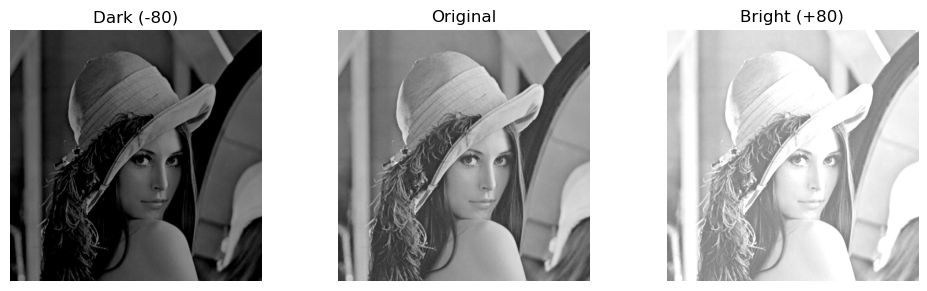

In [10]:
img_gray = cv2.imread("./Images/lena.png", cv2.IMREAD_GRAYSCALE)

# You use + 80 and - 80 to change the exposure of the image:

#     + 80 (Brighten): You are increasing the intensity of every pixel. If a pixel was 100 (dark gray), it becomes 180 (light gray).
#     - 80 (Darken): You are decreasing the intensity. If a pixel was 100, it becomes 20 (almost black).

bright = np.clip(img_gray.astype(np.int16) + 80, 0, 255).astype(np.uint8)
dark   = np.clip(img_gray.astype(np.int16) - 80, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for ax, image, title in zip(axes,
                              [dark, img_gray, bright],
                              ["Dark (-80)", "Original", "Bright (+80)"]):
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis('off')

# tight_layout() calculates the best spacing so that titles, labels, and the images themselves don't overlap and fit neatly within the figure window.
plt.tight_layout()
plt.show()

In [ ]:
# Step 1 — load real noisy image (grayscale)
img = cv2.imread("./Images/noisy.jpg", cv2.IMREAD_GRAYSCALE)
print("Image Resolution:", img.shape)
# Step 2 — crop a small patch (small enough to read pixel values)
patch = img[40:70, 30:60]   # 30×30 patch

print("Patch shape:", patch.shape)   # (10, 10)
print("Patch values:\n", patch)      # raw pixel values          

Image Resolution: (140, 148)
Patch shape: (30, 30)
Patch values:
 [[102 106  97 154 202 182 149 137 118 105  99 115 109 118 102 123 118 124
  114 120 131 145 154 153 143 134 140 144 140 144]
 [103 106 101 159 200 180 152 142 128 117 110 119 110 119 109 128 120 120
  122 131 143 151 152 149 145 142 142 153 157 154]
 [105 106 105 165 196 178 157 148 138 129 119 118 106 113 112 128 120 117
  128 137 145 146 139 136 140 146 141 150 155 154]
 [107 107 103 171 192 177 162 149 142 133 118 111 100 102 108 121 122 121
  136 139 139 135 129 131 140 149 150 142 143 147]
 [107 107  98 177 191 179 168 146 141 132 117 106  99  95 107 115 127 132
  145 140 133 128 130 137 147 153 154 142 145 150]
 [103 101  93 185 193 183 174 144 141 135 127 111 107 100 117 119 135 139
  140 133 126 126 133 141 146 146 136 133 153 159]
 [ 96  92  92 193 197 187 179 144 147 146 143 121 118 111 134 128 137 133
  129 127 128 133 141 144 140 135 128 123 149 160]
 [ 91  84  93 199 199 189 182 146 154 156 155 128 124 118 1